# Experiment C-4


Training CNN on MNIST...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7575 - loss: 0.8181 - val_accuracy: 0.9105 - val_loss: 0.2865
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9429 - loss: 0.1958 - val_accuracy: 0.9365 - val_loss: 0.1948
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9657 - loss: 0.1214 - val_accuracy: 0.9550 - val_loss: 0.1573
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


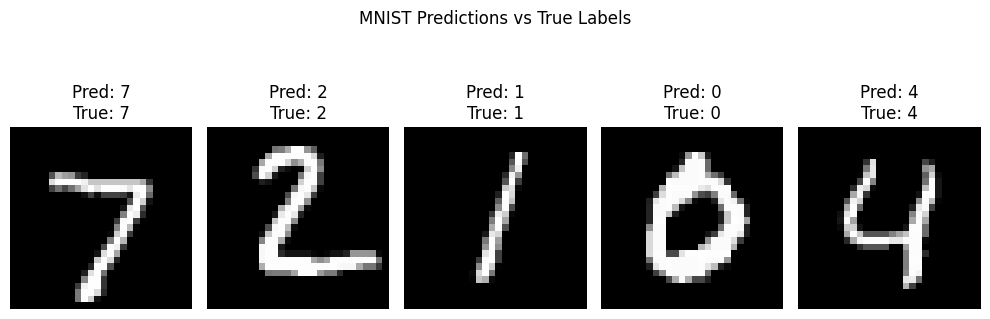

In [2]:
"""C-4: MNIST handwritten digit detection."""

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

# 1. Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. Build a simple CNN
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Train the model (using a subset for faster execution in practicals)
print("Training CNN on MNIST...")
model.fit(x_train[:10000], y_train[:10000], epochs=3, validation_data=(x_test[:2000], y_test[:2000]))

# 4. Predict and plot output images
predictions = model.predict(x_test[:5])

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
    plt.axis('off')

plt.suptitle("MNIST Predictions vs True Labels")
plt.tight_layout()
plt.show()
